In [37]:
# Import required Python modules.
import pandas as pd
import numpy as np
import yfinance as yf

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D

In [36]:
# get SPY price data from Yahoo Finance

ticker = 'SPY'
start_date = "1995-01-01"
end_date = "2026-09-22"

ohlcv = yf.download(
    ticker, 
    start=start_date, 
    end=end_date, 
    #group_by="Ticker",
    auto_adjust=False,
    progress=False,        # suppress download progress output
)
ohlcv = ohlcv.stack('Ticker', future_stack=True ).reset_index().set_index('Date')
ohlcv

Price,Ticker,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,,
1995-01-03,SPY,26.378323,45.781250,45.843750,45.687500,45.703125,324300
1995-01-04,SPY,26.504362,46.000000,46.000000,45.750000,45.984375,351800
1995-01-05,SPY,26.504362,46.000000,46.109375,45.953125,46.031250,89800
1995-01-06,SPY,26.531370,46.046875,46.250000,45.906250,46.093750,448400
1995-01-09,SPY,26.558374,46.093750,46.093750,46.000000,46.031250,36800
...,...,...,...,...,...,...,...
2026-09-15,SPY,755.513916,757.390015,760.349976,756.150024,760.119995,46195000
2026-09-16,SPY,752.182190,754.049988,761.669983,749.599976,759.500000,59217700
2026-09-17,SPY,760.710999,762.599976,763.570007,759.960022,763.150024,49652800


In [45]:
# uniema and rsi indicator functions

def uniema(price, length=14, poles=2, order=3,
           weight_factor=2.0, damping_factor=0.5):
    
    """Universal EMA with configurable poles, order, weight, and damping."""
    price = np.asarray(price, dtype=float)

    if length < 1 or poles < 1 or order < 1:
        raise ValueError("length, poles, and order must be >= 1")
    if price.size == 0:
        return np.array([], dtype=float)

    alpha = order * weight_factor / (
        length + order * weight_factor - 1
    )
    beta = 1 - alpha

    state = np.full((order, poles), price[0], dtype=float)
    result = np.empty_like(price)
    result[0] = price[0]

    for t in range(1, len(price)):
        value = price[t]

        for k in range(order):
            for j in range(poles):
                state[k, j] = beta * state[k, j] + alpha * value

                value = (
                    state[k, j]
                    if j == 0
                    else value + damping_factor *
                    (state[k, 0] - state[k, j])
                )

        result[t] = value

    return result


def rsi(close, length=14, method="WILDERS",
        poles=2, order=3, weight_factor=1.0,
        damping_factor=0.5):
    """RSI using Wilder or UniEMA smoothing."""
    is_series = isinstance(close, pd.Series)
    index = close.index if is_series else None
    price = np.asarray(close, dtype=float)
    method = method.upper()

    if price.ndim != 1:
        raise ValueError("close must be one-dimensional")
    if length < 1:
        raise ValueError("length must be >= 1")
    if method not in {"WILDERS", "UNIEMA"}:
        raise ValueError("method must be 'WILDERS' or 'UNIEMA'")
    if price.size == 0:
        result = np.array([], dtype=float)
        return pd.Series(result, index=index, name="RSI") if is_series else result
    if np.isnan(price).any():
        raise ValueError("close contains NaN values")

    change = np.diff(price, prepend=price[0])
    gain = np.maximum(change, 0)
    loss = np.maximum(-change, 0)

    if method == "WILDERS":
        poles, order, weight_factor, damping_factor = 1, 1, 1.0, 0.0

    args = (
        length, poles, order,
        weight_factor, damping_factor,
    )

    average_gain = uniema(gain, *args)
    average_loss = uniema(loss, *args)

    strength = np.divide(
        average_gain,
        average_loss,
        out=np.full_like(average_gain, np.inf),
        where=average_loss != 0,
    )

    result = 100 - 100 / (1 + strength)
    result[(average_gain == 0) & (average_loss == 0)] = 50

    if is_series:
        return pd.Series(
            result,
            index=index,
            name=f"RSI_{length}_{method}",
        )

    return result

# Plot price with trend-colored UniEMA and trading signals, 
# together with RSI and regime-colored UniRSI

def plot_signals(df, title="UniEMA and UniRSI"):
    dates = pd.to_datetime(
        df["Date"]
        if "Date" in df.columns
        else df.index.get_level_values(0)
    )

    x = mdates.date2num(dates)

    close = df["Close"].to_numpy()
    uniema = df["UniEMA"].to_numpy()
    rsi = df["RSI"].to_numpy()
    unirsi = df["UniRSI"].to_numpy()
    signal2 = df["Signal 2"].to_numpy()
    signal = df["Signal"].ffill().fillna(0).to_numpy()

    def colored_line(ax, x, y, colors, width=1.8):
        points = np.column_stack([x, y])
        segments = np.stack(
            [points[:-1], points[1:]],
            axis=1,
        )

        collection = LineCollection(
            segments,
            colors=np.asarray(colors)[1:],
            linewidth=width,
        )

        ax.add_collection(collection)
        ax.autoscale_view()

    fig, (ax1, ax2) = plt.subplots(
        2,
        1,
        figsize=(9, 6),
        sharex=True,
        gridspec_kw={"height_ratios": [2, 1]},
    )

    # --------------------------------------------------
    # Price panel
    # --------------------------------------------------

    ax1.plot(
        x,
        close,
        color="black",
        linewidth=0.9,
    )

    # Combined trading regime
    ax1.fill_between(
        x,
        0,
        1,
        where=signal == 1,
        transform=ax1.get_xaxis_transform(),
        color="green",
        alpha=0.08,
        step="post",
    )

    ax1.fill_between(
        x,
        0,
        1,
        where=signal == 0,
        transform=ax1.get_xaxis_transform(),
        color="red",
        alpha=0.04,
        step="post",
    )

    # UniEMA slope colors
    ema_colors = np.where(
        uniema >= np.r_[uniema[0], uniema[:-1]],
        "green",
        "red",
    )

    colored_line(
        ax1,
        x,
        uniema,
        ema_colors,
        width=2,
    )

    # Buy and sell markers
    signal_change = np.diff(
        signal,
        prepend=signal[0],
    )

    buy = signal_change == 1
    sell = signal_change == -1

    ax1.scatter(
        x[buy],
        close[buy],
        marker="^",
        color="green",
        edgecolor="black",
        linewidth=0.4,
        s=55,
        zorder=5,
    )

    ax1.scatter(
        x[sell],
        close[sell],
        marker="v",
        color="red",
        edgecolor="black",
        linewidth=0.4,
        s=55,
        zorder=5,
    )

    ax1.set_title(title)
    ax1.set_ylabel("Price")
    ax1.grid(alpha=0.25)

    ax1.legend(handles=[
        Line2D([], [], color="black", label="Close"),
        Line2D([], [], color="green", lw=2, label="UniEMA rising"),
        Line2D([], [], color="red", lw=2, label="UniEMA falling"),
        Line2D(
            [], [],
            marker="^",
            color="green",
            markeredgecolor="black",
            linestyle="",
            label="Buy",
        ),
        Line2D(
            [], [],
            marker="v",
            color="red",
            markeredgecolor="black",
            linestyle="",
            label="Sell",
        ),
    ])

    # --------------------------------------------------
    # RSI panel
    # --------------------------------------------------

    ax2.plot(
        x,
        rsi,
        color="gray",
        linewidth=1,
    )

    # UniRSI colors from Signal 2
    unirsi_colors = np.where(
        signal2 == 1,
        "green",
        np.where(signal2 == 0, "red", "gray"),
    )

    colored_line(
        ax2,
        x,
        unirsi,
        unirsi_colors,
        width=1.8,
    )

    ax2.axhline(70, color="red", linestyle="--", alpha=0.5)
    ax2.axhline(50, color="gray", linestyle=":", alpha=0.6)
    ax2.axhline(45, color="orange", linestyle=":", alpha=0.6)
    ax2.axhline(30, color="green", linestyle="--", alpha=0.5)

    ax2.set_ylim(0, 100)
    ax2.set_ylabel("RSI")
    #ax2.set_xlabel("Date")
    ax2.grid(alpha=0.25)

    ax2.legend(handles=[
        Line2D([], [], color="gray", label="RSI"),
        Line2D([], [], color="green", lw=2, label="UniRSI buy"),
        Line2D([], [], color="red", lw=2, label="UniRSI sell"),
    ])

    ax2.xaxis_date()
    ax2.xaxis.set_major_formatter(
        mdates.DateFormatter("%Y-%m")
    )

    fig.autofmt_xdate()
    fig.tight_layout()
    plt.show()

    return
    



In [46]:
def run_calculations(ohlcv):
    
    # Remove rows with missing closing prices before calculating indicators
    df = ohlcv.dropna(subset=["Close"]).copy()
    
    # Calculate UniEMA, standard Wilder RSI, and UniEMA-smoothed RSI
    df['UniEMA'] = uniema(df['Close'],15,2,3,2,0.7)
    df['RSI'] = rsi(df['Close'], 14)
    df['UniRSI'] = rsi(df['Close'], 14, "UNIEMA",2,3,1,0.5)
    
    return df

df =  run_calculations(ohlcv)
df

Price,Ticker,Adj Close,Close,High,Low,Open,Volume,UniEMA,RSI,UniRSI
Date,,,,,,,,,,
1995-01-03,SPY,26.378323,45.781250,45.843750,45.687500,45.703125,324300,45.781250,50.000000,50.000000
1995-01-04,SPY,26.504362,46.000000,46.000000,45.750000,45.984375,351800,45.800788,100.000000,100.000000
1995-01-05,SPY,26.504362,46.000000,46.109375,45.953125,46.031250,89800,45.836034,100.000000,100.000000
1995-01-06,SPY,26.531370,46.046875,46.250000,45.906250,46.093750,448400,45.882040,100.000000,100.000000
1995-01-09,SPY,26.558374,46.093750,46.093750,46.000000,46.031250,36800,45.934437,100.000000,100.000000
...,...,...,...,...,...,...,...,...,...,...
2026-09-15,SPY,755.513916,757.390015,760.349976,756.150024,760.119995,46195000,762.504361,44.408928,41.443625
2026-09-16,SPY,752.182190,754.049988,761.669983,749.599976,759.500000,59217700,760.777762,41.762943,39.398772
2026-09-17,SPY,760.710999,762.599976,763.570007,759.960022,763.150024,49652800,759.669994,49.979101,39.705493


In [47]:
# here is one example of how to generate trading signals from the 
# uniema, unirsi indicators. there are many other ways.
def trading_logic(df):
    """
    Generate a long/cash trading signal using UniEMA trend direction
    and a UniRSI momentum regime.

    Signal 1:
        1 when UniEMA is rising; otherwise 0.

    Signal 2:
        1 when UniRSI rises above 50.
        0 when UniRSI falls below 45.
        Retains its previous state between 45 and 50.

    Combined signal:
        Enter long when both signals equal 1.
        Exit when both signals equal 0.
        Retain the current position when the signals disagree.
    """

    # Identify the current UniEMA trend direction
    df["Signal 1"] = np.where(
        df["UniEMA"] > df["UniEMA"].shift(1), 1, 0
    )

    # Create a UniRSI regime with 50/45 hysteresis
    df["Signal 2"] = np.where(df["UniRSI"] > 50, 1, np.nan)
    df["Signal 2"] = np.where(
        df["UniRSI"] < 45, 0, df["Signal 2"]
    )

    # Initialize in cash and retain the last confirmed regime
    df.at[df.index[0], "Signal 2"] = 0
    df["Signal 2"] = df["Signal 2"].ffill()

    # Enter when both trend and momentum are bullish
    cond_buy = (
        (df["Signal 1"] == 1) &
        (df["Signal 2"] == 1)
    )
    df["Signal"] = np.where(cond_buy, 1, np.nan)

    # Exit when both trend and momentum are bearish
    cond_sell = (
        (df["Signal 1"] == 0) &
        (df["Signal 2"] == 0)
    )
    df["Signal"] = np.where(
        cond_sell, 0, df["Signal"]
    )

    # Initialize in cash and hold the last confirmed position
    df.at[df.index[0], "Signal"] = 0
    df["Signal"] = df["Signal"].ffill()

    return df
df = trading_logic(df)
df

Price,Ticker,Adj Close,Close,High,Low,Open,Volume,UniEMA,RSI,UniRSI,Signal 1,Signal 2,Signal
Date,,,,,,,,,,,,,
1995-01-03,SPY,26.378323,45.781250,45.843750,45.687500,45.703125,324300,45.781250,50.000000,50.000000,0,0.0,0.0
1995-01-04,SPY,26.504362,46.000000,46.000000,45.750000,45.984375,351800,45.800788,100.000000,100.000000,1,1.0,1.0
1995-01-05,SPY,26.504362,46.000000,46.109375,45.953125,46.031250,89800,45.836034,100.000000,100.000000,1,1.0,1.0
1995-01-06,SPY,26.531370,46.046875,46.250000,45.906250,46.093750,448400,45.882040,100.000000,100.000000,1,1.0,1.0
1995-01-09,SPY,26.558374,46.093750,46.093750,46.000000,46.031250,36800,45.934437,100.000000,100.000000,1,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-09-15,SPY,755.513916,757.390015,760.349976,756.150024,760.119995,46195000,762.504361,44.408928,41.443625,0,0.0,0.0
2026-09-16,SPY,752.182190,754.049988,761.669983,749.599976,759.500000,59217700,760.777762,41.762943,39.398772,0,0.0,0.0
2026-09-17,SPY,760.710999,762.599976,763.570007,759.960022,763.150024,49652800,759.669994,49.979101,39.705493,0,0.0,0.0


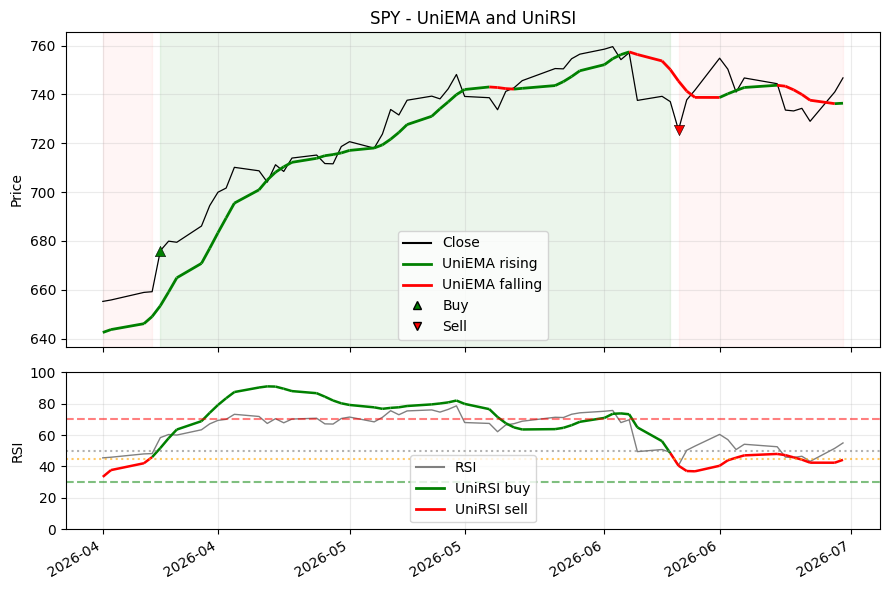

In [48]:
plot_signals(df['2026-04':'2026-06'], title="SPY - UniEMA and UniRSI")